C:\Users\AUSTCSE4090\anaconda3\envs\py310\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train images: 20
Test images: 8
Datasets ready: train_ds, test_ds
Total patches: 121


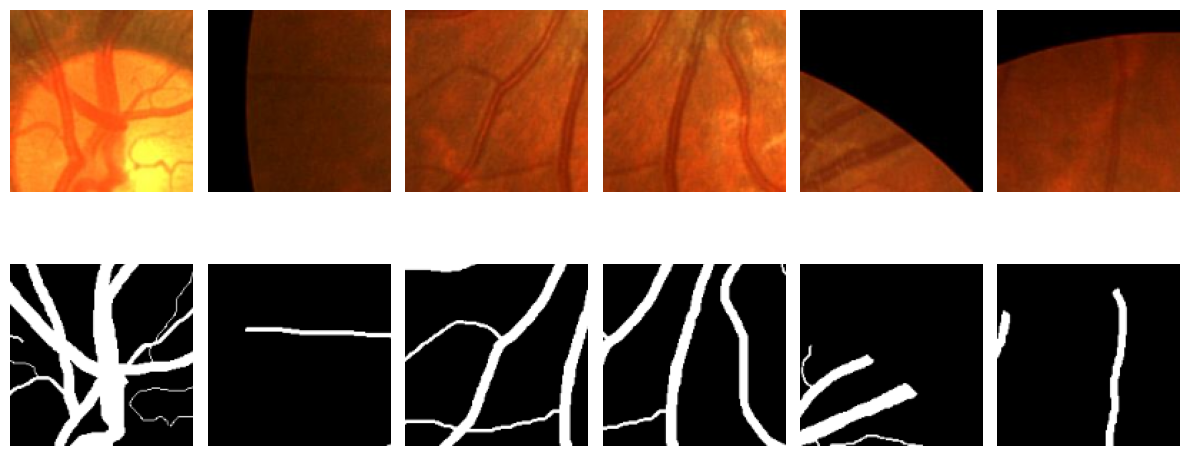

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import matplotlib.pyplot as plt
import random

# ================= PATHS =================
IMG_DIR = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_images"
MASK_DIR = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\processed\CHASEDB1_1stHO"

# ================= CONSTANTS =================
RESIZE_SIZE = 768  # Resize original images to 768x768
IMG_SIZE = 128     # Patch size
OVERLAP = 0.5
BATCH_SIZE = 8

# ================= AUGMENTATION =================
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
])

# ================= FUNCTIONS =================
def is_valid_patch(mask, threshold=0.01):
    return np.count_nonzero(mask) / mask.size > threshold

def extract_patches(img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    stride = int(patch_size * (1 - overlap))
    patches_img = []
    patches_mask = []
    H, W = img.shape[:2]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            p_img = img[y:y+patch_size, x:x+patch_size]
            p_mask = mask[y:y+patch_size, x:x+patch_size]

            if skip_empty and not is_valid_patch(p_mask):
                continue

            patches_img.append(p_img)
            patches_mask.append(p_mask)

    return patches_img, patches_mask

def load_image_mask_paths(image_dir, mask_dir):
    image_files = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    return image_files, mask_files

def generator(image_paths, mask_paths, augment=True, skip_empty=True):
    for img_path, mask_path in zip(image_paths, mask_paths):

        # Read images
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize to 768x768
        img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
        mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

        # Extract patches
        patches_img, patches_mask = extract_patches(
            img, mask, IMG_SIZE, OVERLAP, skip_empty
        )

        for p_img, p_mask in zip(patches_img, patches_mask):

            if augment:
                data = augmenter(image=p_img, mask=p_mask)
                p_img, p_mask = data["image"], data["mask"]

            p_img = p_img.astype(np.float32) / 255.0
            p_mask = np.expand_dims(p_mask.astype(np.float32) / 255.0, axis=-1)

            yield p_img, p_mask

# ================= LOAD PATHS =================
all_images, all_masks = load_image_mask_paths(IMG_DIR, MASK_DIR)

# ===== Manual split: FIRST 20 → train, LAST 8 → test =====
train_images = all_images[:20]
train_masks  = all_masks[:20]

test_images  = all_images[20:]
test_masks   = all_masks[20:]

print(f"Train images: {len(train_images)}")
print(f"Test images: {len(test_images)}")

# ================= TF.DATA DATASETS =================
train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_images, train_masks, augment=True, skip_empty=True),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_images, test_masks, augment=False, skip_empty=False),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets ready: train_ds, test_ds")

# ================= VISUALIZATION =================
def visualize_patches(img_path, mask_path, num_samples=6):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize for visualization
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
    mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

    patches_img, patches_mask = extract_patches(
        img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=False
    )

    print(f"Total patches: {len(patches_img)}")

    indices = random.sample(range(len(patches_img)), min(num_samples, len(patches_img)))

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        plt.subplot(2, num_samples, i+1)
        plt.imshow(patches_img[idx])
        plt.axis("off")

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(patches_mask[idx], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example visualization
visualize_patches(train_images[0], train_masks[0])


In [2]:
import tensorflow as tf
from tensorflow.keras import backend as K

def confusion_elements(y_true, y_pred):
    """Helper to calculate TP, TN, FP, FN"""
    y_pred = K.round(y_pred)
    y_true = K.round(y_true)
    TP = K.sum(y_true * y_pred)
    TN = K.sum((1 - y_true) * (1 - y_pred))
    FP = K.sum((1 - y_true) * y_pred)
    FN = K.sum(y_true * (1 - y_pred))
    return TP, TN, FP, FN

# Sensitivity (Recall)
def sensitivity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FN + K.epsilon())

# Specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TN / (TN + FP + K.epsilon())

# Accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN + K.epsilon())

# Precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FP + K.epsilon())

# F1-score
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = sensitivity(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec + K.epsilon()))

# AUC (use Keras built-in metric)
auc = tf.keras.metrics.AUC(name='auc')


import tensorflow as tf
import tensorflow.keras.backend as K

smooth = 1e-6

def iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(K.round(y_pred), tf.float32)  # Round to binary
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(K.round(y_pred))  # Round predictions to binary
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [3]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, Add,
    Activation, Concatenate, BatchNormalization, Lambda, Multiply
)
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

# ---------------------------
# Utility: match spatial size
# ---------------------------
def match_spatial_size(tensors):
    """
    Resize-with-crop-or-pad `skip` to the spatial size of `up`.
    tensors: list/tuple of [up, skip]
    """
    up, skip = tensors
    up_shape = tf.shape(up)
    target_h = up_shape[1]
    target_w = up_shape[2]
    # tf.image.resize_with_crop_or_pad handles both cropping and padding
    skip_matched = tf.image.resize_with_crop_or_pad(skip, target_h, target_w)
    return skip_matched

# ---------------------------
# Recurrent Residual Block (R2)
# ---------------------------
def rec_res_block(input_layer, out_channels, t=2, batch_norm=False, name_prefix="r2"):
    x = input_layer
    in_channels = K.int_shape(x)[-1]
    # If channels mismatch, project with 1x1 conv
    if in_channels != out_channels:
        x = Conv2D(out_channels, (1,1), padding='same', name=f"{name_prefix}_proj")(x)

    x_initial = x
    # Recurrent residual loop
    for i in range(t):
        if i == 0:
            x1 = Conv2D(out_channels, (3,3), padding='same', name=f"{name_prefix}_conv_{i}_a")(x)
            if batch_norm:
                x1 = BatchNormalization(name=f"{name_prefix}_bn_{i}_a")(x1)
            x1 = Activation('relu', name=f"{name_prefix}_act_{i}_a")(x1)

        x1 = Conv2D(out_channels, (3,3), padding='same', name=f"{name_prefix}_conv_{i}_b")(Add(name=f"{name_prefix}_add_{i}")([x, x1]))
        if batch_norm:
            x1 = BatchNormalization(name=f"{name_prefix}_bn_{i}_b")(x1)
        x1 = Activation('relu', name=f"{name_prefix}_act_{i}_b")(x1)

        # Update x for next recurrence
        x = x1

    out = Add(name=f"{name_prefix}_res_add")([x, x_initial])
    return out

# ---------------------------
# Attention Gate
# ---------------------------
def attention_gate(x, g, inter_channels=None, name_prefix="att"):
    """
    x: skip connection tensor (shape: batch, H, W, C_x)
    g: gating tensor (usually decoder feature map) (shape: batch, h, w, C_g)
    inter_channels: intermediate channels for attention; if None, use max(1, C_g // 2)
    returns: x * sigmoid( psi( ReLU( theta_x(x) + phi_g(g) ) ) )
    """
    Cg = K.int_shape(g)[-1]
    Cx = K.int_shape(x)[-1]

    if inter_channels is None:
        inter_channels = max(1, Cg // 2)

    theta_x = Conv2D(inter_channels, (1,1), padding='same', name=f"{name_prefix}_theta_x")(x)
    phi_g   = Conv2D(inter_channels, (1,1), padding='same', name=f"{name_prefix}_phi_g")(g)

    add_xg = Activation('relu', name=f"{name_prefix}_relu")(
        Add(name=f"{name_prefix}_add")([theta_x, phi_g])
    )

    psi = Conv2D(1, (1,1), padding='same', name=f"{name_prefix}_psi")(add_xg)
    psi = Activation('sigmoid', name=f"{name_prefix}_sigmoid")(psi)

    # psi has shape (batch, H, W, 1) -> multiply with x (broadcast along channel dim)
    out = Multiply(name=f"{name_prefix}_mul")([x, psi])
    return out

# ---------------------------
# Up + Attention + Concat
# ---------------------------
def attention_up_and_concate(down_layer, skip_layer, name_prefix="up_att"):
    # 2x upsample decoder feature
    up = UpSampling2D(size=(2,2), interpolation='nearest', name=f"{name_prefix}_upsample")(down_layer)

    # Match skip spatially to up using a Lambda layer (dynamic-safe)
    skip_matched = Lambda(match_spatial_size, name=f"{name_prefix}_match")([up, skip_layer])

    # compute inter channels robustly using up channels
    up_channels = K.int_shape(up)[-1] or tf.shape(up)[-1]
    inter_ch = max(1, (up_channels // 2) if isinstance(up_channels, int) else 1)

    # Attention gate
    attn_skip = attention_gate(skip_matched, up, inter_channels=inter_ch, name_prefix=f"{name_prefix}_attgate")

    # Concatenate along channels
    out = Concatenate(axis=-1, name=f"{name_prefix}_concat")([up, attn_skip])
    return out

# ---------------------------
# Attention R2U-Net constructor
# ---------------------------
def att_r2_unet(img_h, img_w, n_label, t=2, base_filters=64, depth=4, batch_norm=False):
    inputs = Input((img_h, img_w, 3), name="input")
    x = inputs
    features = base_filters
    skips = []

    # Encoder path
    for i in range(depth):
        x = rec_res_block(x, features, t=t, batch_norm=batch_norm, name_prefix=f"enc{i}")
        skips.append(x)
        x = MaxPooling2D((2,2), name=f"pool{i}")(x)
        features *= 2

    # Bottleneck
    x = rec_res_block(x, features, t=t, batch_norm=batch_norm, name_prefix="bottleneck")

    # Decoder path
    for i in reversed(range(depth)):
        features //= 2
        # Project x to 'features' channels before upsampling if necessary (keeps decoder stable)
        cur_channels = K.int_shape(x)[-1]
        if cur_channels != features:
            x = Conv2D(features, (1,1), padding='same', name=f"dec_proj_{i}")(x)

        x = attention_up_and_concate(x, skips[i], name_prefix=f"dec{i}_upatt")
        # After concat, channels = features (up) + skip_channels (which typically == features)
        # Run rec_res_block to process and reduce if needed
        x = rec_res_block(x, features, t=t, batch_norm=batch_norm, name_prefix=f"dec{i}")

    # Final 1x1 conv for segmentation map
    out_activation = 'sigmoid' if n_label == 1 or n_label > 1 else 'softmax'
    out = Conv2D(n_label, (1,1), padding='same', activation='sigmoid' if n_label == 1 else 'softmax', name="final_conv")(x)


    model = Model(inputs, out, name="AttR2UNet")
    return model

# ---------------------------
# Example: build and show summary
# ---------------------------
if __name__ == "__main__":
    model = att_r2_unet(128, 128, n_label=1, t=2, base_filters=32, depth=4, batch_norm=True)
    model.summary()


Model: "AttR2UNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 enc0_proj (Conv2D)             (None, 128, 128, 32  128         ['input[0][0]']                  
                                )                                                                 
                                                                                                  
 enc0_conv_0_a (Conv2D)         (None, 128, 128, 32  9248        ['enc0_proj[0][0]']              
                                )                                                         

In [4]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ----------------------------------
# Tversky Index
# ----------------------------------
def tversky(y_true, y_pred, alpha=0.7, beta=0.3):
    # numerical stability
    y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)

    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    

    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)

    return (true_pos + 1e-6) / (
        true_pos + alpha * false_neg + beta * false_pos + 1e-6
    )


# ----------------------------------
# Focal Tversky Loss
# ----------------------------------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    tv = tversky(y_true, y_pred)
    return K.pow((1 - tv), gamma)


# ----------------------------------
# Hybrid Loss (Recommended)
# ----------------------------------
def hybrid_loss(y_true, y_pred):
    ft = focal_tversky_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.7 * ft + 0.3 * bce


In [5]:
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.optimizers import Adam


# Define Adam optimizer with an initial learning rate
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)


def lr_schedule(epoch, lr):
    if epoch < 5:  # Warmup phase
        return lr * 1.5  # Increase LR to stabilize training
    elif epoch < 30:
        return lr * 0.98  # Gradual decay
    else:
        return lr * 0.95  # Final stabilization

lr_scheduler = LearningRateScheduler(lr_schedule)

In [7]:
from tensorflow.keras.losses import BinaryCrossentropy
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True),
    lr_scheduler
    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]



# Compile the model
model.compile(
    optimizer=optimizer,
    loss= hybrid_loss,  # Use BCE loss for binary segmentation
    metrics=[sensitivity, specificity, accuracy, f1_score, auc,dice_coef,iou]  # Your custom metrics
)


# Fit the model
history = model.fit(
    train_ds,
    #validation_data=test_ds,
     # optional if dataset is finite
    epochs=80,
)


Epoch 1/80
274/274 [==============================] - 15s 25ms/step - loss: 0.4717 - sensitivity: 0.6104 - specificity: 0.9390 - accuracy: 0.9081 - f1_score: 0.5533 - auc: 0.8725 - dice_coef: 0.5520 - iou: 0.3933
Epoch 2/80
274/274 [==============================] - 7s 24ms/step - loss: 0.3563 - sensitivity: 0.7536 - specificity: 0.9576 - accuracy: 0.9390 - f1_score: 0.6864 - auc: 0.9270 - dice_coef: 0.6841 - iou: 0.5228
Epoch 3/80
274/274 [==============================] - 7s 24ms/step - loss: 0.3234 - sensitivity: 0.7878 - specificity: 0.9618 - accuracy: 0.9458 - f1_score: 0.7209 - auc: 0.9369 - dice_coef: 0.7181 - iou: 0.5627
Epoch 4/80
274/274 [==============================] - 7s 24ms/step - loss: 0.3028 - sensitivity: 0.8100 - specificity: 0.9643 - accuracy: 0.9501 - f1_score: 0.7418 - auc: 0.9436 - dice_coef: 0.7387 - iou: 0.5879
Epoch 5/80
274/274 [==============================] - 7s 24ms/step - loss: 0.2899 - sensitivity: 0.8213 - specificity: 0.9660 - accuracy: 0.9526 - f1_s

Dice        : 0.7943
IoU         : 0.6590
Accuracy    : 0.9710
F1-score    : 0.7943
Sensitivity : 0.8860
Specificity : 0.9767
AUC         : 0.9889


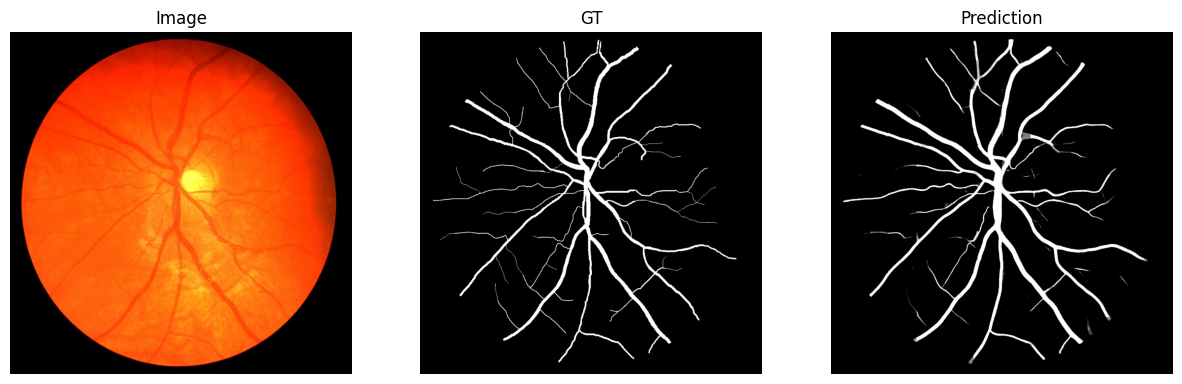

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix

# ================= CONFIG =================
RESIZE_SIZE = 768
PATCH_SIZE  = 128
OVERLAP     = 0.5
STRIDE      = int(PATCH_SIZE * (1 - OVERLAP))
BATCH_SIZE  = 16          # GPU safe
THRESHOLD   = 0.5

# ================= PATCH UTILS =================
def extract_patches(img):
    H, W = img.shape[:2]
    for y in range(0, H - PATCH_SIZE + 1, STRIDE):
        for x in range(0, W - PATCH_SIZE + 1, STRIDE):
            yield img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

def stitch_patches(patches):
    full = np.zeros((RESIZE_SIZE, RESIZE_SIZE), np.float32)
    count = np.zeros_like(full)

    idx = 0
    for y in range(0, RESIZE_SIZE - PATCH_SIZE + 1, STRIDE):
        for x in range(0, RESIZE_SIZE - PATCH_SIZE + 1, STRIDE):
            full[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += patches[idx]
            count[y:y+PATCH_SIZE, x:x+PATCH_SIZE] += 1
            idx += 1

    return np.clip(full / (count + 1e-7), 0, 1)

# ================= FULL IMAGE PRED =================
def predict_full_image(model, img_path):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))

    patches = list(extract_patches(img))
    preds_all = []

    for i in range(0, len(patches), BATCH_SIZE):
        batch = np.array(patches[i:i+BATCH_SIZE], np.float32) / 255.0
        preds = model.predict(batch, verbose=0)
        preds_all.extend(preds[..., 0])

    return img, stitch_patches(preds_all)

# ================= EVALUATION =================
def evaluate_model(model, image_paths, mask_paths):
    dice_l, iou_l, acc_l, f1_l, se_l, sp_l, auc_l = [], [], [], [], [], [], []

    for img_p, mask_p in zip(image_paths, mask_paths):
        _, pred = predict_full_image(model, img_p)

        gt = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
        gt = cv2.resize(gt, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

        y_prob = pred.flatten()
        y_pred = (pred >= THRESHOLD).astype(np.uint8).flatten()
        y_true = (gt >= 0.5).astype(np.uint8).flatten()

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()

        dice = (2*tp) / (2*tp + fp + fn + 1e-7)
        iou  = tp / (tp + fp + fn + 1e-7)
        acc  = (tp + tn) / (tp + tn + fp + fn + 1e-7)
        se   = tp / (tp + fn + 1e-7)
        sp   = tn / (tn + fp + 1e-7)
        f1   = f1_score(y_true, y_pred)
        auc  = roc_auc_score(y_true, y_prob)

        dice_l.append(dice)
        iou_l.append(iou)
        acc_l.append(acc)
        f1_l.append(f1)
        se_l.append(se)
        sp_l.append(sp)
        auc_l.append(auc)

    print(f"Dice        : {np.mean(dice_l):.4f}")
    print(f"IoU         : {np.mean(iou_l):.4f}")
    print(f"Accuracy    : {np.mean(acc_l):.4f}")
    print(f"F1-score    : {np.mean(f1_l):.4f}")
    print(f"Sensitivity : {np.mean(se_l):.4f}")
    print(f"Specificity : {np.mean(sp_l):.4f}")
    print(f"AUC         : {np.mean(auc_l):.4f}")

# ================= VISUALIZATION =================
def visualize(model, img_path, mask_path):
    img, pred = predict_full_image(model, img_path)
    gt = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt = cv2.resize(gt, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(gt, cmap="gray"); plt.title("GT"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(pred, cmap="gray"); plt.title("Prediction"); plt.axis("off")
    plt.show()

# ================= RUN =================
evaluate_model(model, test_images, test_masks)
visualize(model, test_images[0], test_masks[0])

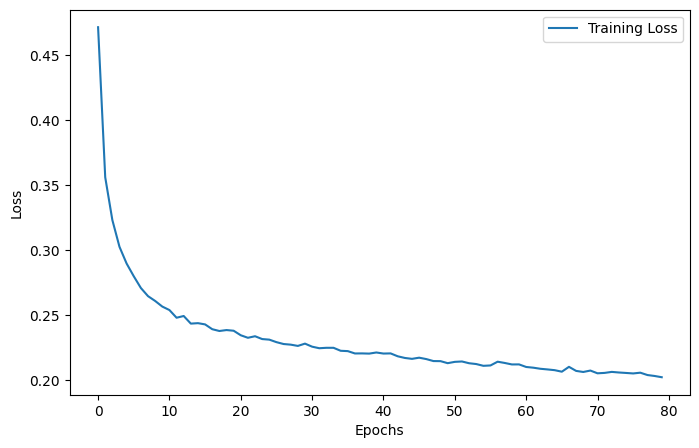

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Metrics for Image 1: Sens: 0.916, Spec: 0.979, Acc: 0.976, F1: 0.802, Dice: 0.802, IoU: 0.670


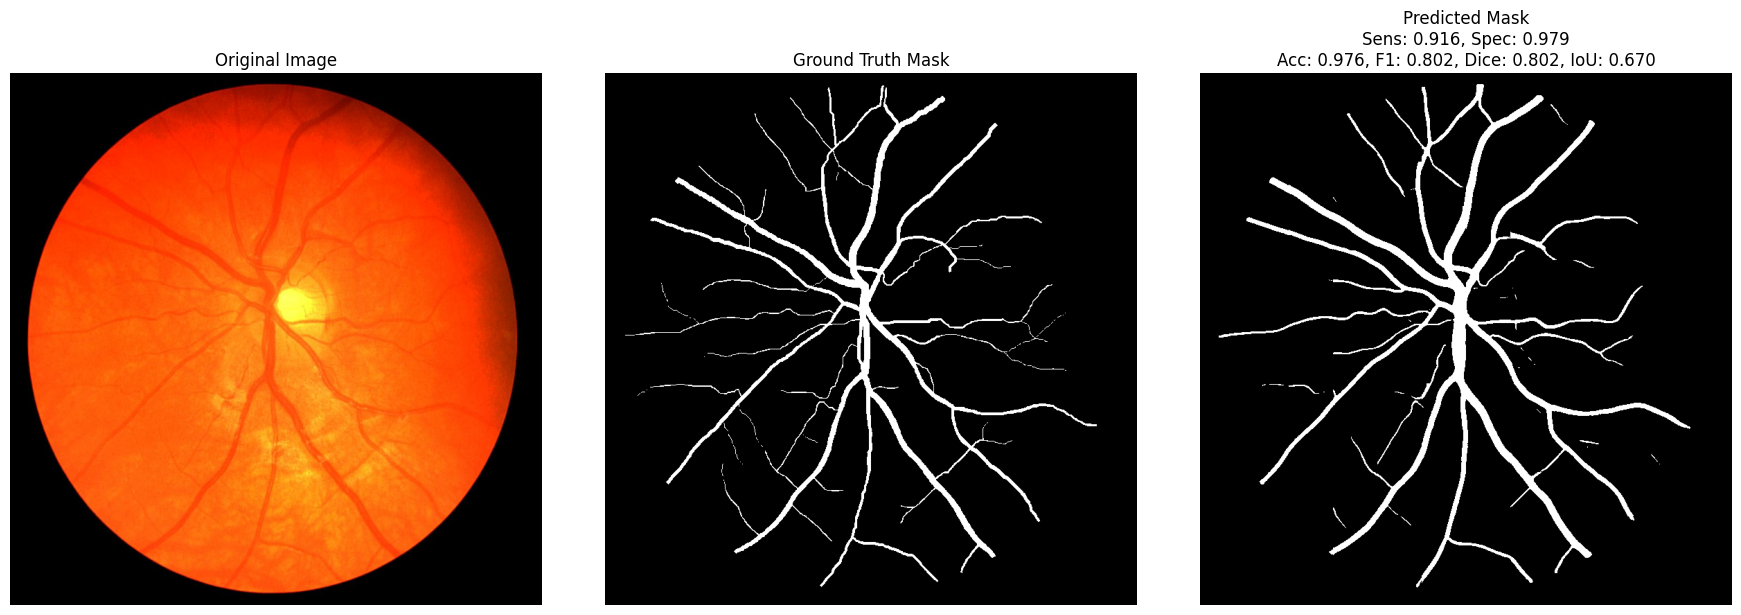

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_1.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_1.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_1.png
Metrics for Image 1 written to CSV.
Metrics for Image 2: Sens: 0.905, Spec: 0.981, Acc: 0.977, F1: 0.805, Dice: 0.805, IoU: 0.673


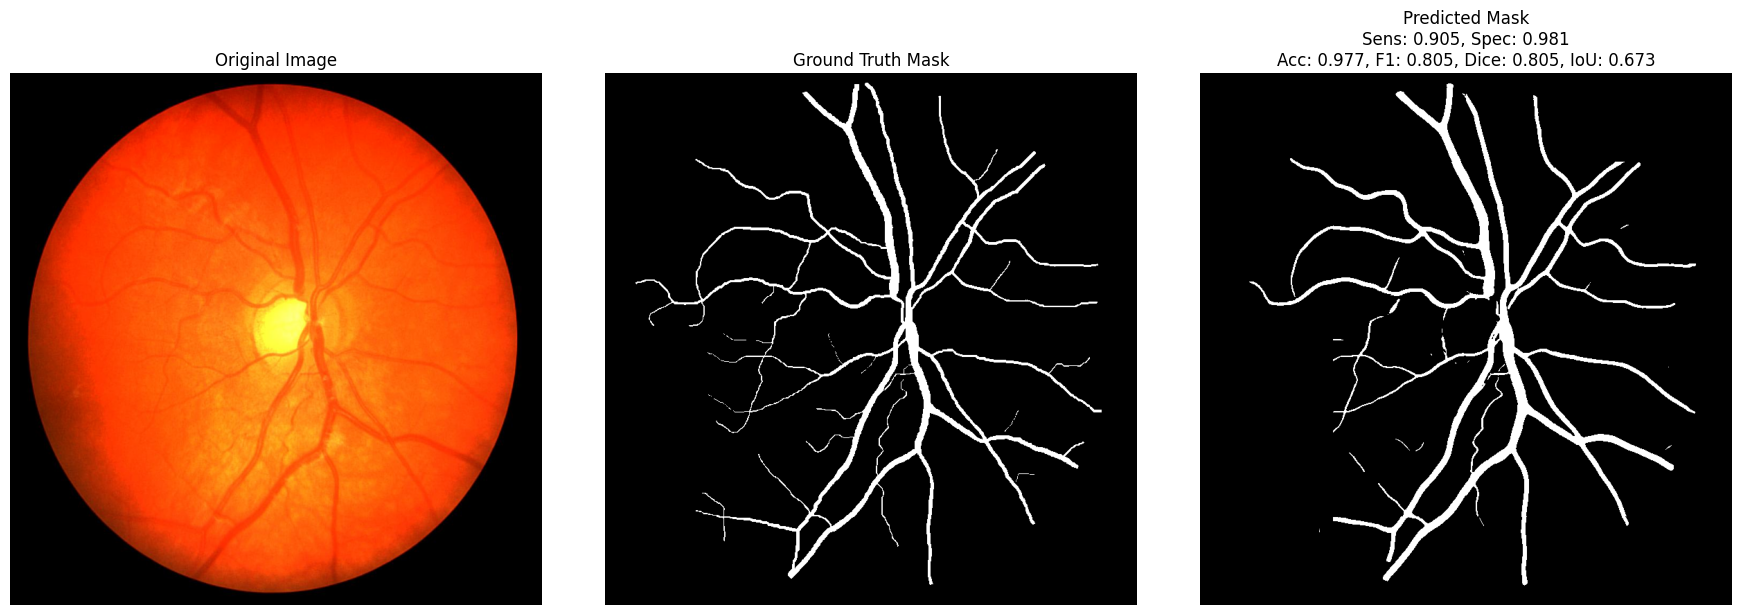

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_2.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_2.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_2.png
Metrics for Image 2 written to CSV.
Metrics for Image 3: Sens: 0.890, Spec: 0.968, Acc: 0.963, F1: 0.773, Dice: 0.773, IoU: 0.630


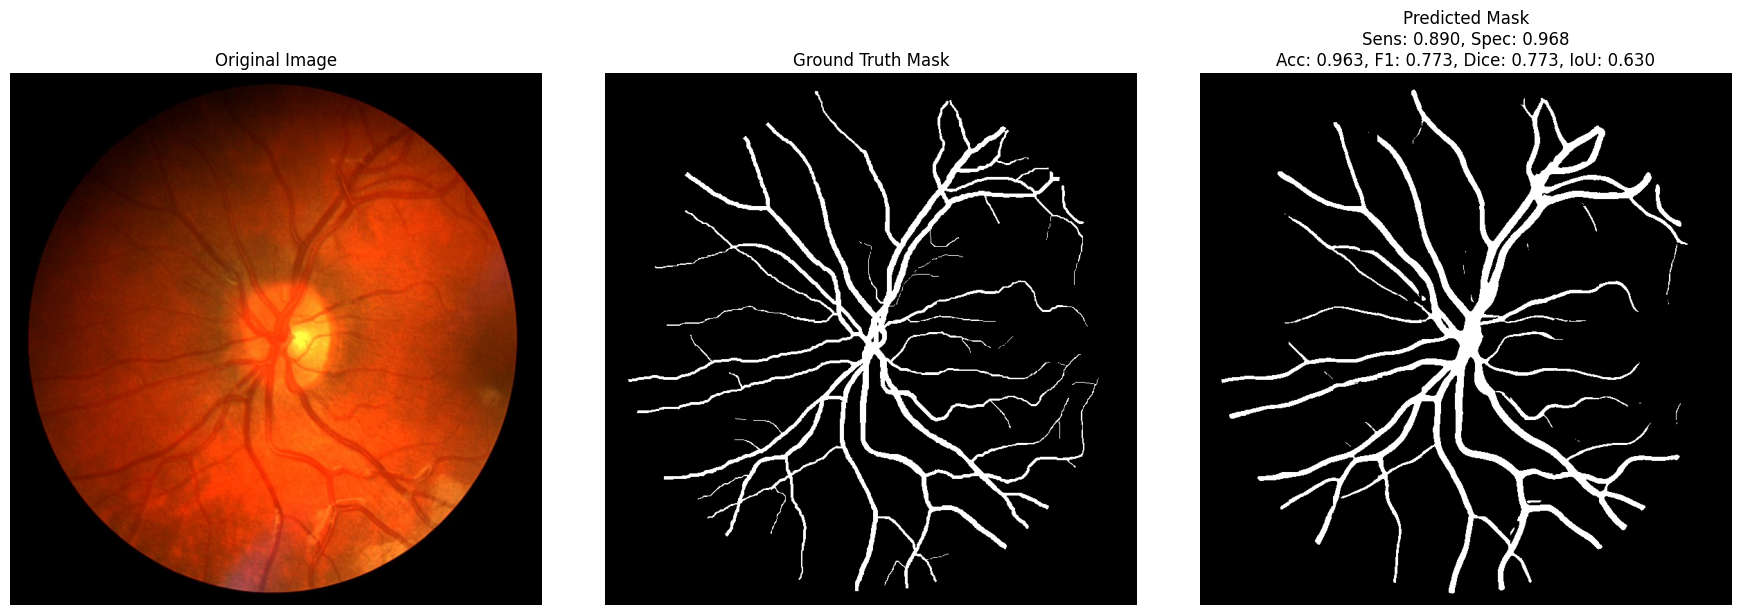

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_3.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_3.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_3.png
Metrics for Image 3 written to CSV.
Metrics for Image 4: Sens: 0.903, Spec: 0.970, Acc: 0.965, F1: 0.793, Dice: 0.793, IoU: 0.657


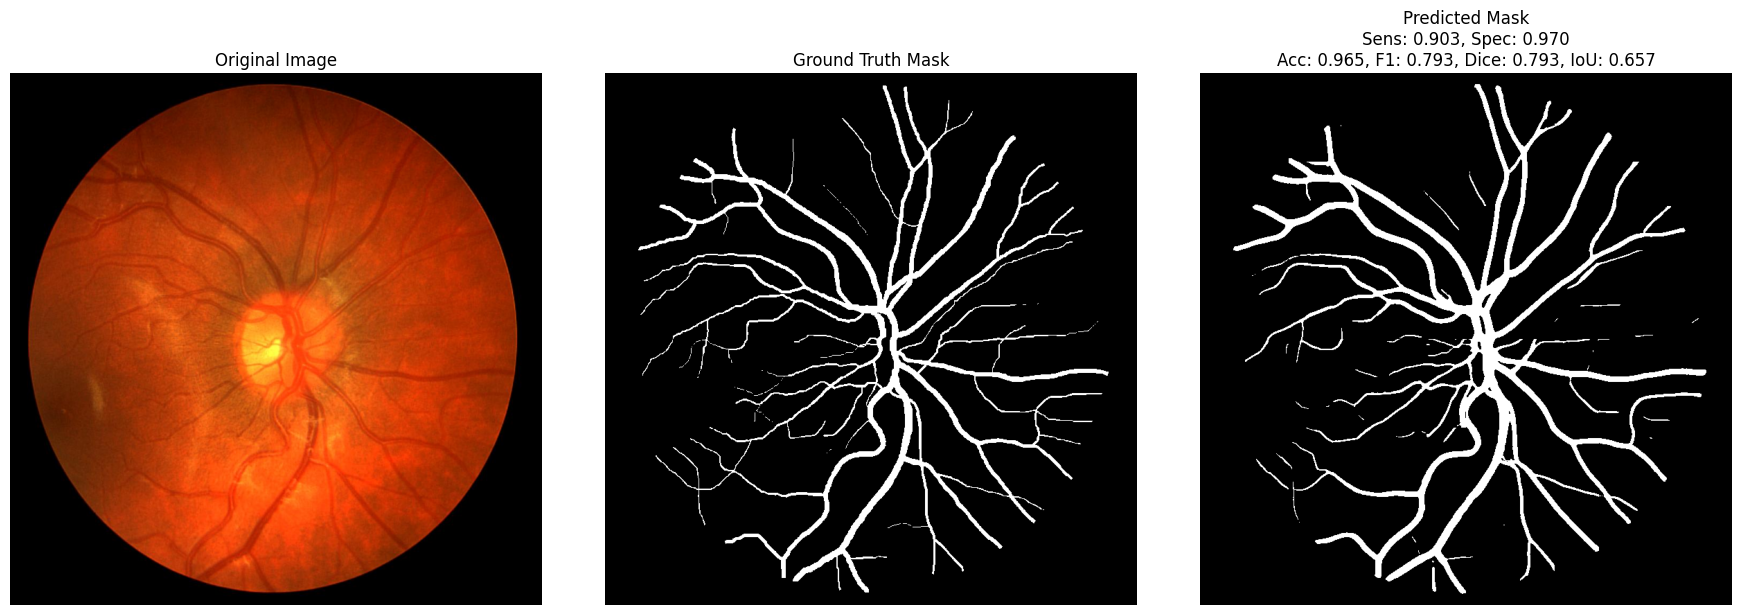

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_4.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_4.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_4.png
Metrics for Image 4 written to CSV.
Metrics for Image 5: Sens: 0.885, Spec: 0.979, Acc: 0.973, F1: 0.801, Dice: 0.801, IoU: 0.669


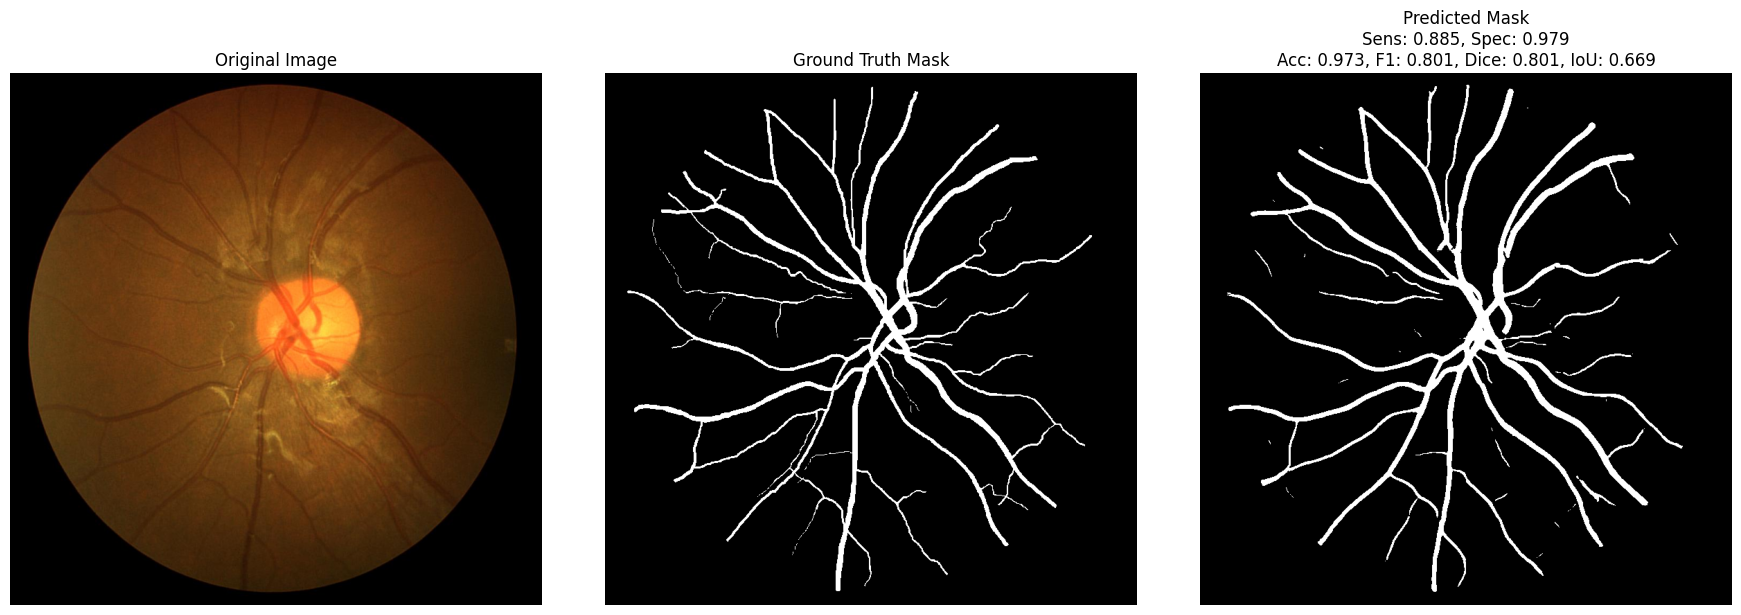

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_5.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_5.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_5.png
Metrics for Image 5 written to CSV.
Metrics for Image 6: Sens: 0.855, Spec: 0.979, Acc: 0.971, F1: 0.787, Dice: 0.787, IoU: 0.648


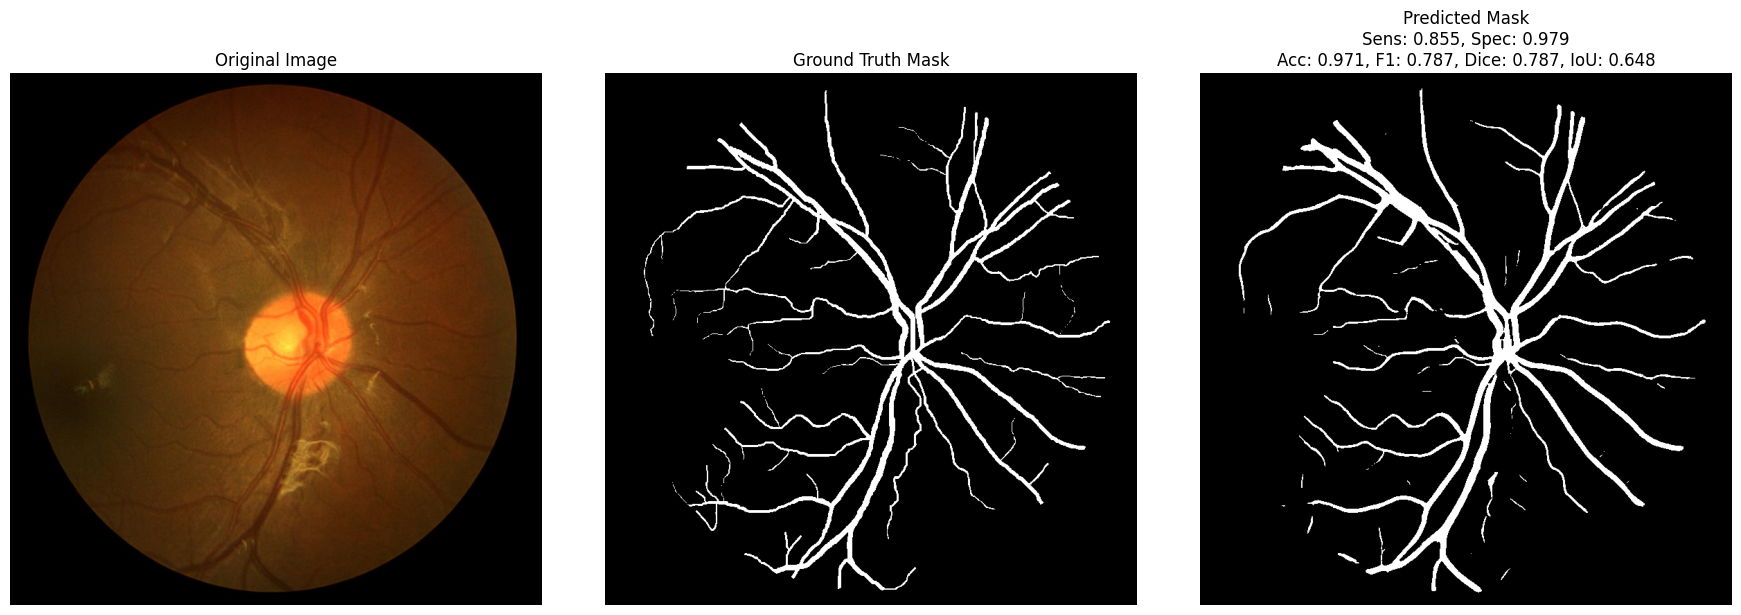

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_6.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_6.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_6.png
Metrics for Image 6 written to CSV.
Metrics for Image 7: Sens: 0.873, Spec: 0.980, Acc: 0.973, F1: 0.816, Dice: 0.816, IoU: 0.689


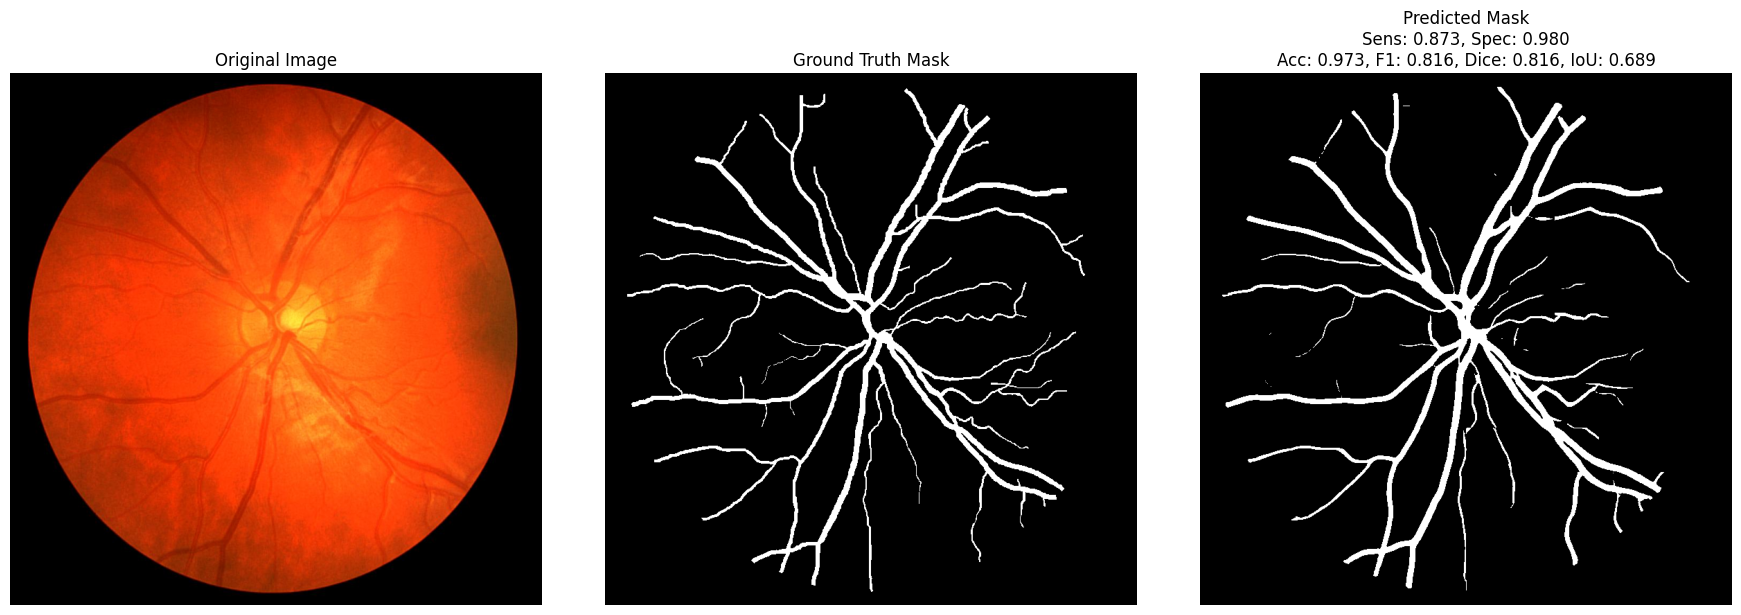

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_7.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_7.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_7.png
Metrics for Image 7 written to CSV.
Metrics for Image 8: Sens: 0.863, Spec: 0.978, Acc: 0.971, F1: 0.778, Dice: 0.778, IoU: 0.636


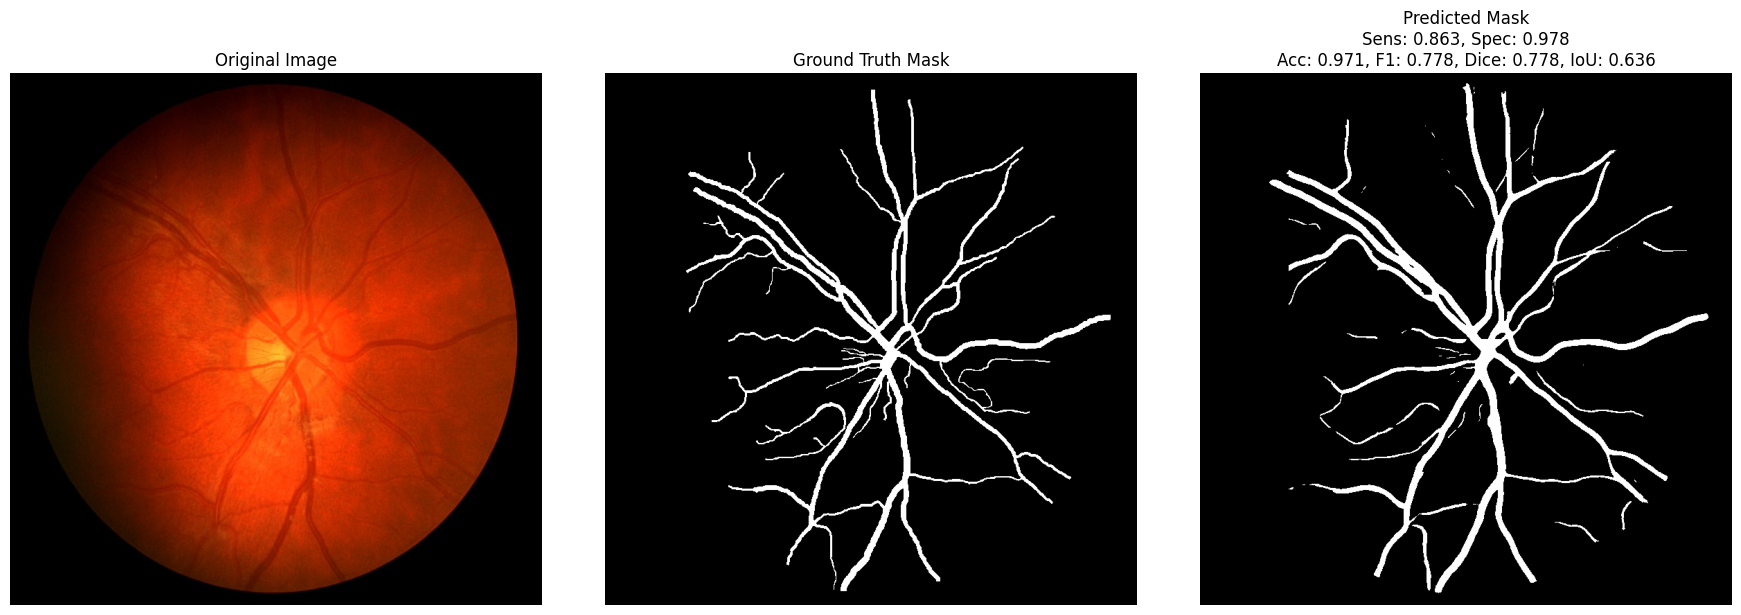

Saved original image: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images\original_image_8.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask\predicted_mask_8.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask\ground_truth_mask_8.png
Metrics for Image 8 written to CSV.
All test image metrics saved to C:\Users\AUSTCSE4090\Desktop\CHASEDB\attr2_unetfinal__metrics.csv


In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

# Directories to save predictions, ground truth masks, and original images
PREDICTIONS_DIR = r'C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__predicted_mask'
GROUND_TRUTH_DIR = r'C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal__ground_truth_mask'
ORIGINAL_IMAGES_DIR = r'C:\Users\AUSTCSE4090\Desktop\CHASEDB\predicted_mask\attr2_unetfinal_original_images'
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(GROUND_TRUTH_DIR, exist_ok=True)
os.makedirs(ORIGINAL_IMAGES_DIR, exist_ok=True)

# Constants
THRESHOLD = 0.5
RESIZE_SIZE = 768
CSV_FILE = r"C:\Users\AUSTCSE4090\Desktop\CHASEDB\attr2_unetfinal__metrics.csv"

# Define the function to save predicted masks
def save_predicted_mask(pred_mask, idx):
    mask_bin = (pred_mask > THRESHOLD).astype(np.uint8) * 255  # Binarize
    save_path = os.path.join(PREDICTIONS_DIR, f"predicted_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved predicted mask: {save_path}")

# Define the function to save ground truth masks
def save_ground_truth_mask(gt_mask, idx):
    mask_bin = (gt_mask * 255).astype(np.uint8)  # Ensure it is in 0-255 range
    save_path = os.path.join(GROUND_TRUTH_DIR, f"ground_truth_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved ground truth mask: {save_path}")

# Define the function to save the original images
def save_original_image(img, idx):
    save_path = os.path.join(ORIGINAL_IMAGES_DIR, f"original_image_{idx + 1}.png")
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR for saving with OpenCV
    cv2.imwrite(save_path, img_bgr)
    print(f"Saved original image: {save_path}")

# Function to compute per-image metrics
def compute_metrics_per_image(y_true, y_pred):
    y_true = y_true.astype(np.uint8)
    y_pred = y_pred.astype(np.uint8)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    sensitivity = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    f1_score = 2 * precision * sensitivity / (precision + sensitivity + 1e-6)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-6)
    iou = TP / (TP + FP + FN + 1e-6)

    return sensitivity, specificity, accuracy, f1_score, dice, iou

# Initialize CSV file and write header
def initialize_csv():
    with open(CSV_FILE, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Image_Index", "Sensitivity", "Specificity", "Accuracy", "F1_Score", "Dice", "IoU"])

# Write metrics to CSV
def write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou):
    with open(CSV_FILE, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([idx + 1, sens, spec, acc, f1, dice, iou])
    print(f"Metrics for Image {idx + 1} written to CSV.")

# Modify the visualization function to show original image, ground truth, and predicted mask
def visualize_metrics_and_save_prediction(model, img_path, mask_path, idx):
    # Predict mask for the image
    img, pred_mask = predict_full_image(model, img_path)  # Ensure this function is defined
    
    # Check if the prediction and image are correct
    if img is None or pred_mask is None:
        print(f"Prediction failed for image {img_path}")
        return

    # Read and preprocess the ground truth mask
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0
    
    # Apply thresholding to both ground truth and predicted masks to ensure they are binary
    gt_mask_bin = (gt_mask >= 0.5).astype(np.uint8)  # Ground truth as binary (0 or 1)
    pred_mask_bin = (pred_mask >= THRESHOLD).astype(np.uint8)  # Predicted mask as binary (0 or 1)
    
    # Compute metrics
    sens, spec, acc, f1, dice, iou = compute_metrics_per_image(gt_mask_bin, pred_mask_bin)
    
    # Print the metrics to verify if they are being calculated correctly
    print(f"Metrics for Image {idx + 1}: Sens: {sens:.3f}, Spec: {spec:.3f}, Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")

    # Plot the original image, ground truth, and predicted mask
    plt.figure(figsize=(18, 6))  # Increase the size to accommodate all 3 images
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    
    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title(f"Predicted Mask\nSens: {sens:.3f}, Spec: {spec:.3f}\n"
              f"Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    # Save the original image, predicted mask, and ground truth mask
    save_original_image(img, idx)
    save_predicted_mask(pred_mask, idx)
    save_ground_truth_mask(gt_mask, idx)

    # Write the metrics to the CSV file
    write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou)

# Initialize the CSV file with the header
initialize_csv()

# Example usage: 
for idx, (img_path, mask_path) in enumerate(zip(test_images, test_masks)):
    visualize_metrics_and_save_prediction(model, img_path, mask_path, idx)

print(f"All test image metrics saved to {CSV_FILE}")


In [12]:
import os

# Define the folder path to save the model
folder_path = r'C:\Users\AUSTCSE4090\Desktop\chasedb\prediction'  # Update this path if needed
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Define the model save path
model_save_path = os.path.join(folder_path, 'attentionr2final_unet_model.h5')

# Save the model in H5 format
model.save(model_save_path)
print(f"Saved model to {model_save_path}")


Saved model to C:\Users\AUSTCSE4090\Desktop\chasedb\prediction\attentionr2final_unet_model.h5


In [17]:
from tensorflow.keras import backend as K

# Clear any previous models and free memory
K.clear_session()
